In [1]:
from pathlib import Path
import numpy as np
from astropy.io import fits

def first_3d_hdu(fp):
    with fits.open(fp, memmap=True) as hdul:
        for i, h in enumerate(hdul):
            if getattr(h, "data", None) is None:
                continue
            if hasattr(h.data, "ndim") and h.data.ndim == 3:
                return i, h.data.shape, h.header
    return None, None, None

def build_wave_from_header(hdr, nw):
    crval = hdr.get("CRVAL3", None)
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3", None))
    crpix = hdr.get("CRPIX3", 1.0)
    if crval is None or cdelt is None:
        return None
    pix = np.arange(nw, dtype=float) + 1.0
    return crval + (pix - crpix) * cdelt

root = Path.cwd()
fits_files = sorted(root.rglob("*.fits")) + sorted(root.rglob("*.fit")) + sorted(root.rglob("*.fz"))

cands = []
for fp in fits_files:
    name = fp.name.lower()

    # hard exclude products that are NOT the input/orig cube
    if ("_line_cube" in name) or ("_cont_cube" in name) or ("_gas_" in name) or ("_spatial_" in name):
        continue

    ext, shape, hdr = first_3d_hdu(fp)
    if ext is None:
        continue

    nw, ny, nx = shape
    wave = build_wave_from_header(hdr, nw)
    if wave is None:
        continue

    # require "9100-like" coverage (tolerant)
    if not (wave.max() > 8900 and wave.min() < 5000):
        continue

    # score by keywords
    score = 0
    for kw in ["ic3392", "datacube", "input", "final", "orig"]:
        if kw in name:
            score += 3
    # prefer bigger cubes
    score += int(np.prod(shape) / 1e8)

    cands.append((score, fp, ext, shape, wave.min(), wave.max()))

cands = sorted(cands, key=lambda t: (-t[0], -np.prod(t[3])))

print("Candidate ORIG cubes for 9100-like range:")
for s, fp, ext, shape, wmin, wmax in cands[:15]:
    print(f"score={s:3d} ext={ext} shape={shape}  wave~[{wmin:.1f},{wmax:.1f}] -> {fp.relative_to(root)}")

if len(cands) == 0:
    print("\nNo 9100-like ORIG cube found under pwd (excluding line/cont cubes).")
    print("=> You should set ORIG_FP manually to the input cube used in the config.")


Candidate ORIG cubes for 9100-like range:

No 9100-like ORIG cube found under pwd (excluding line/cont cubes).
=> You should set ORIG_FP manually to the input cube used in the config.


In [2]:
from pathlib import Path
import numpy as np
from astropy.io import fits

run_ids = {
    8:  "IC3392_v3tk_9100_mask_uptoCONT_MDEG8",
    12: "IC3392_v3tk_9100_mask_uptoCONT_MDEG12",
    14: "IC3392_v3tk_9100_mask_uptoCONT_MDEG14",
    16: "IC3392_v3tk_9100_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_9100_mask_uptoCONT_MDEG20",
}
REF_MDEG = 14

def build_wave_from_header(hdr, nw):
    crval = hdr.get("CRVAL3", None)
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3", None))
    crpix = hdr.get("CRPIX3", 1.0)
    if crval is None or cdelt is None:
        raise ValueError("Missing CRVAL3 and/or CDELT3/CD3_3 in header.")
    pix = np.arange(nw, dtype=float) + 1.0
    return crval + (pix - crpix) * cdelt

def extract_spec(cube, x, y):
    return cube[:, y, x]  # (nw, ny, nx)

hdul_line = {}
line_cube = {}

for mdeg, rid in run_ids.items():
    fp = Path.cwd() / rid / f"{rid}_line_cube.fits"
    hdul_line[mdeg] = fits.open(fp, memmap=True)
    line_cube[mdeg] = hdul_line[mdeg][0].data
    print(f"MDEG {mdeg}: {fp.name} shape={line_cube[mdeg].shape}")

# wavelength from ref
hdr = hdul_line[REF_MDEG][0].header
nw, ny, nx = line_cube[REF_MDEG].shape
wave = build_wave_from_header(hdr, nw)
print("wave range:", wave.min(), wave.max())

MDEG 8: IC3392_v3tk_9100_mask_uptoCONT_MDEG8_line_cube.fits shape=(3459, 438, 437)
MDEG 12: IC3392_v3tk_9100_mask_uptoCONT_MDEG12_line_cube.fits shape=(3459, 438, 437)
MDEG 14: IC3392_v3tk_9100_mask_uptoCONT_MDEG14_line_cube.fits shape=(3459, 438, 437)
MDEG 16: IC3392_v3tk_9100_mask_uptoCONT_MDEG16_line_cube.fits shape=(3459, 438, 437)
MDEG 20: IC3392_v3tk_9100_mask_uptoCONT_MDEG20_line_cube.fits shape=(3459, 438, 437)
wave range: 4827.5 9150.0


In [3]:
from pathlib import Path
import numpy as np
from astropy.io import fits

# ORIG cube for continuum-based sampling (edit ORIG_FP if needed)
ORIG_FP = Path("/Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits")
CONT_WIN = (5218.0, 5485.0)
GAL_CONT_PCTL = 30.0
NSAMPLE = 600
SEED = 42

orig_ext, orig_shape, orig_hdr = first_3d_hdu(ORIG_FP)
if orig_ext is None:
    raise FileNotFoundError(f"No 3D HDU found in ORIG_FP={ORIG_FP}")

with fits.open(ORIG_FP, memmap=True) as h:
    orig_cube = h[orig_ext].data
    wave_orig = build_wave_from_header(h[orig_ext].header, orig_cube.shape[0])
    if wave_orig is None:
        raise ValueError("Missing CRVAL3/CDELT3 in ORIG cube header.")
    cont_sel = (wave_orig >= CONT_WIN[0]) & (wave_orig <= CONT_WIN[1])
    cont_map = np.nanmedian(orig_cube[cont_sel, :, :], axis=0)

cont_ok = np.isfinite(cont_map)
cont_p90 = np.nanpercentile(np.abs(cont_map[cont_ok]), 90)
cont_floor = cont_p90 * 1e-3
cont_thr = np.nanpercentile(cont_map[cont_ok], GAL_CONT_PCTL)
gal_mask = cont_ok & (cont_map > cont_thr)

print(f"ORIG cube: {ORIG_FP} shape={orig_shape}")
print(f"CONT_WIN {CONT_WIN} p90(|cont|)={cont_p90:.3g} floor={cont_floor:.3g}")
print(f"Galaxy mask threshold p{GAL_CONT_PCTL}={cont_thr:.3g} -> N={gal_mask.sum()}")

ORIG cube: /Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits shape=(3761, 438, 437)
CONT_WIN (5218.0, 5485.0) p90(|cont|)=68.2 floor=0.0682
Galaxy mask threshold p30.0=9.36 -> N=67634


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/2415250995.py:22: RuntimeWarning: All-NaN slice encountered
  cont_map = np.nanmedian(orig_cube[cont_sel, :, :], axis=0)


[SAMPLE] galaxy-mask pixels: 67634
[SAMPLE] using 600 spaxels


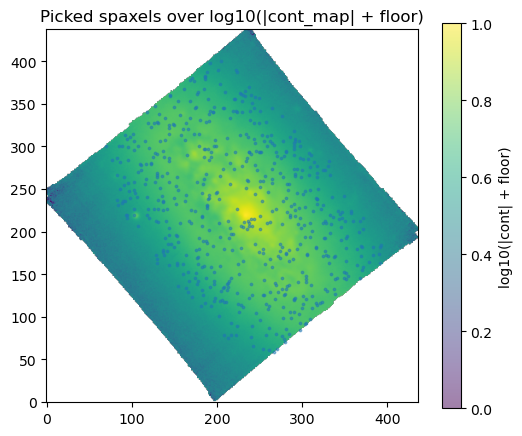

In [4]:
import numpy as np
import matplotlib.pyplot as plt

yy, xx = np.where(gal_mask)
n_valid = yy.size
if n_valid == 0:
    raise RuntimeError("No spaxels in galaxy mask. Lower GAL_CONT_PCTL.")

rng = np.random.default_rng(SEED)
take = min(NSAMPLE, n_valid)
sel_idx = rng.choice(n_valid, size=take, replace=False)

ys = yy[sel_idx]
xs = xx[sel_idx]
spax = np.column_stack([xs, ys]).astype(int)
cont_spax = cont_map[ys, xs]

print(f"[SAMPLE] galaxy-mask pixels: {n_valid}")
print(f"[SAMPLE] using {take} spaxels")

plt.figure(figsize=(6, 5))
plt.imshow(np.log10(np.abs(cont_map) + cont_floor), origin="lower")
plt.scatter(spax[:, 0], spax[:, 1], s=3, alpha=0.5)
plt.title("Picked spaxels over log10(|cont_map| + floor)")
plt.colorbar(label="log10(|cont| + floor)")
plt.show()

In [5]:
import numpy as np
import pandas as pd

# -----------------------------
# Settings
# -----------------------------
WMIN, WMAX = 4800, 9100  
sel = (wave >= WMIN) & (wave <= WMAX)
wave_sel = wave[sel]

windows = {
    "cont_5050_5120": (5050.0, 5120.0),
    "cont_5218_5485": (5218.0, 5485.0),
    "cont_5600_5650": (5600.0, 5650.0),
    "cont_6000_6200": (6000.0, 6200.0),
    "cont_6400_6500": (6400.0, 6500.0),
    "Hb_edge_4800_4920": (4800.0, 4920.0),
    "OIII_edge_4940_5060": (4940.0, 5060.0),
    "HaNII_edge_6500_6625": (6500.0, 6625.0),
    "SII_edge_6680_6760": (6680.0, 6760.0),
    "ArIII_edge_7085_7185": (7085.0, 7185.0),
    "OII_edge_7285_7355": (7285.0, 7355.0),
    "cont_8200_8250": (8200.0, 8250.0),
    "sky_8440_8455": (8440.0, 8455.0),
    "CaT_edge_8470_8700": (8470.0, 8700.0),
    "cont_8800_8850": (8800.0, 8850.0),
    "SIII_edge_9040_9095": (9040.0, 9095.0),
}

linefree_names = [
    "cont_5050_5120",
    "cont_5218_5485",
    "cont_5600_5650",
    "cont_6000_6200",
    "cont_6400_6500",
    "cont_8200_8250",
    "cont_8800_8850",
]

line_defs = {
    "Hb": {"line": (4850.0, 4875.0), "side": ((4825.0, 4845.0), (4880.0, 4900.0))},
    "OIII": {"line": (5002.0, 5018.0), "side": ((4985.0, 4998.0), (5022.0, 5038.0))},
    "HaNII": {"line": (6548.0, 6583.0), "side": ((6525.0, 6542.0), (6588.0, 6605.0))},
    "SII": {"line": (6715.0, 6740.0), "side": ((6695.0, 6710.0), (6745.0, 6760.0))},
    "ArIII": {"line": (7128.0, 7145.0), "side": ((7105.0, 7120.0), (7150.0, 7168.0))},
    "OII7325": {"line": (7315.0, 7340.0), "side": ((7295.0, 7310.0), (7345.0, 7360.0))},
    "SIII9069": {"line": (9060.0, 9078.0), "side": ((9045.0, 9056.0), (9082.0, 9092.0))},
}

# -----------------------------
# Vector helpers
# -----------------------------
def robust_sigma_mad_2d(A):
    """
    Robust sigma (MAD*1.4826) along axis=0 for a 2D array A (nwave, Nspax).
    Returns shape (Nspax,).
    """
    med = np.nanmedian(A, axis=0)
    mad = np.nanmedian(np.abs(A - med), axis=0)
    return 1.4826 * mad

def window_mask(w1, w2):
    return (wave_sel >= w1) & (wave_sel <= w2)

# Precompute wavelength index masks once
win_masks = [window_mask(*windows[name]) for name in linefree_names]
dl = np.nanmedian(np.diff(wave_sel))  # optional if you want flux*Angstrom units

# -----------------------------
# Extract all spaxels at once
# -----------------------------
xs = spax[:, 0].astype(int)
ys = spax[:, 1].astype(int)
N = spax.shape[0]
mdegs = sorted(run_ids.keys())

cont_spax = cont_map[ys, xs]
cont_denom = np.maximum(np.abs(cont_spax), cont_floor)

window_summary = {wn: {} for wn in windows}

# Reference spectra matrix (nw_sel, N)
Sref = line_cube[REF_MDEG][sel, :, :][:, ys, xs].astype(np.float32, copy=False)
# ensure shape is (nw_sel, N)
if Sref.ndim != 2:
    raise RuntimeError(f"Unexpected Sref shape: {Sref.shape} (expected 2D)")

dfs = []
for mdeg in mdegs:
    S = line_cube[mdeg][sel, :, :][:, ys, xs].astype(np.float32, copy=False)

    # --- 1) baseline leakage proxy (NO smoothing):
    # For each line-free window, measure median offset; baseline_leak = robust sigma across window-median offsets.
    win_meds = []
    for wm in win_masks:
        win_meds.append(np.nanmedian(S[wm, :], axis=0))
    win_meds = np.vstack(win_meds)  # (nwin, N)
    baseline_leak = robust_sigma_mad_2d(win_meds)

    # --- 2) line-free scatter (noise+sky residuals): robust sigma within each window, then median across windows
    win_sig = []
    for wm in win_masks:
        win_sig.append(robust_sigma_mad_2d(S[wm, :]))
    win_sig = np.vstack(win_sig)  # (nwin, N)
    sky_rms = np.nanmedian(win_sig, axis=0)

    # --- 3) difference vs ref in line-free windows
    D = S - Sref
    win_sigD = []
    for wm in win_masks:
        win_sigD.append(robust_sigma_mad_2d(D[wm, :]))
    win_sigD = np.vstack(win_sigD)
    diff_linefree = np.nanmedian(win_sigD, axis=0)

    # --- 4) window-by-window stats
    for wn, (w1, w2) in windows.items():
        wm = window_mask(w1, w2)
        if wm.sum() < 2:
            continue
        win_data = S[wm, :]
        med = np.nanmedian(win_data, axis=0)
        rms = robust_sigma_mad_2d(win_data)
        rmscont = rms / cont_denom
        window_summary[wn][mdeg] = {
            "med_p16": np.nanpercentile(med, 16),
            "med_p50": np.nanpercentile(med, 50),
            "med_p84": np.nanpercentile(med, 84),
            "rms_p16": np.nanpercentile(rms, 16),
            "rms_p50": np.nanpercentile(rms, 50),
            "rms_p84": np.nanpercentile(rms, 84),
            "rmscont_p16": np.nanpercentile(rmscont, 16),
            "rmscont_p50": np.nanpercentile(rmscont, 50),
            "rmscont_p84": np.nanpercentile(rmscont, 84),
            "n": np.isfinite(rmscont).sum(),
        }

    # --- 5) integrated line fluxes with local baseline subtraction (vectorized)
    flux_dict = {}
    for name, ddef in line_defs.items():
        line_win = ddef["line"]
        side_left, side_right = ddef["side"]
        lm = window_mask(*line_win)
        lmask = window_mask(*side_left)
        rmask = window_mask(*side_right)
        if lm.sum() < 2 or (lmask.sum() + rmask.sum()) < 4:
            continue

        # baseline from sidebands (median of concatenated sideband samples)
        side_vals = np.vstack([S[lmask, :], S[rmask, :]])  # (nside, N)
        base = np.nanmedian(side_vals, axis=0)

        # integrate (sum) within line window after subtracting baseline
        F = np.nansum(S[lm, :] - base[None, :], axis=0) * dl
        flux_dict[f"F_{name}"] = F

    dfm = pd.DataFrame({
        "x": xs,
        "y": ys,
        "mdeg": mdeg,
        "baseline_leak": baseline_leak,
        "sky_rms": sky_rms,
        "diff_linefree": diff_linefree,
        **flux_dict
    })
    dfs.append(dfm)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
df.head()

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/2247390995.py:96: RuntimeWarning: All-NaN slice encountered
  win_meds.append(np.nanmedian(S[wm, :], axis=0))
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/2247390995.py:58: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(A, axis=0)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/2247390995.py:59: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(A - med), axis=0)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/2247390995.py:121: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(win_data, axis=0)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/2247390995.py:150: RuntimeWarning: All-NaN slice encountered
  base = np.nanmedian(side_vals, axis=0)


(3000, 13)


,x,y,mdeg,baseline_leak,sky_rms,diff_linefree,F_Hb,F_OIII,F_HaNII,F_SII,F_ArIII,F_OII7325,F_SIII9069
0,129,291,8,0.766343,6.200960,0.101390,-6.416249,16.803223,35.304172,-15.654006,-18.332068,11.515081,-120.959768
1,353,195,8,1.459019,4.402533,0.046452,-44.048901,10.164813,2.848473,-14.294997,-2.413389,7.832220,-9.748386
2,318,269,8,0.327653,4.732049,0.051243,22.838511,-26.384342,-6.324847,25.473716,12.127627,53.682203,0.076880
3,279,289,8,0.342097,4.714794,0.044666,44.174795,-52.487292,-23.209143,-28.816273,27.388010,-44.073181,35.264344
4,269,80,8,1.143393,5.240055,0.057995,115.818138,-45.831170,29.823580,-58.263879,20.201781,-63.024507,-16.300638


,mdeg,median,p16,p84,N
0,8,0.820546,0.448436,1.422367,600
1,12,0.872539,0.479509,1.532221,600
2,14,0.856379,0.484459,1.481092,600
3,16,0.820618,0.443631,1.350831,600
4,20,0.781919,0.451322,1.315617,600


,mdeg,median,p16,p84,N
0,8,5.524530,4.724631,6.654228,600
1,12,5.550966,4.731346,6.666350,600
2,14,5.543279,4.734347,6.591098,600
3,16,5.507726,4.724822,6.617664,600
4,20,5.502790,4.728969,6.572796,600


,mdeg,median,p16,p84,N
0,8,0.064061,0.034475,0.118843,600
1,12,0.048951,0.024335,0.095796,600
2,14,0.000000,0.000000,0.000000,600
3,16,0.045779,0.021857,0.097576,600
4,20,0.058976,0.029941,0.123800,600


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/587338823.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(m) for m in sorted(run_ids)], showfliers=False)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/587338823.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(m) for m in sorted(run_ids)], showfliers=False)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/587338823.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(m) for m in sorted(run_ids)], showfliers=False)


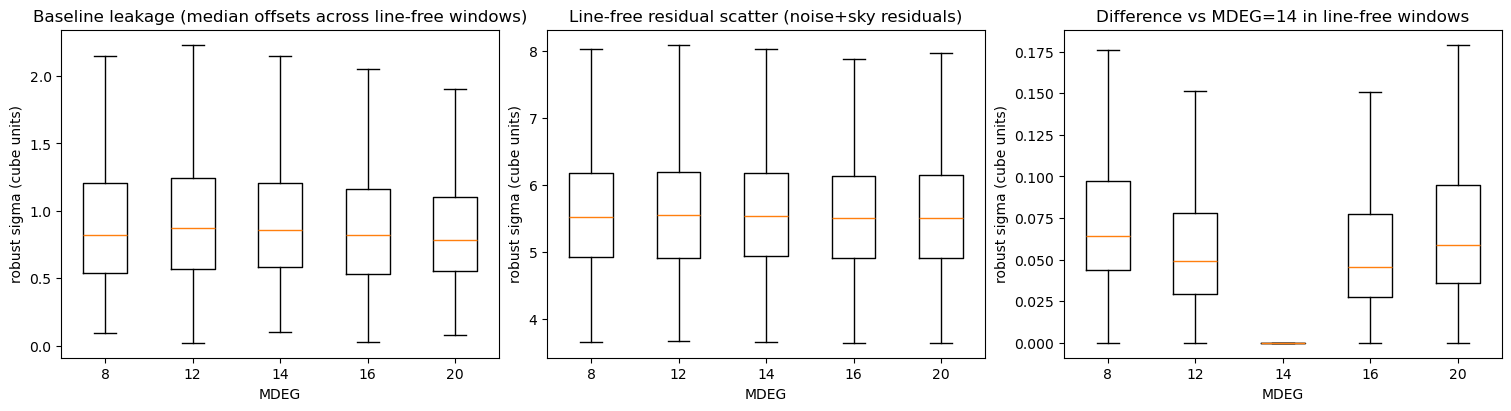


Window: cont_5218_5485


,mdeg,med_p50,rms_p50,rmscont_p50,n
0,8,0.213374,6.376789,0.192244,600
1,12,0.342000,6.385385,0.191523,600
2,14,0.250624,6.356400,0.192011,600
3,16,0.251449,6.358707,0.191969,600
4,20,0.339673,6.377555,0.191867,600



Window: cont_8200_8250


,mdeg,med_p50,rms_p50,rmscont_p50,n
0,8,0.036636,4.047285,0.123633,596
1,12,0.332085,4.050467,0.124937,596
2,14,0.390592,4.064998,0.125463,596
3,16,0.533437,4.061900,0.125801,596
4,20,0.513712,4.070239,0.123895,596



Window: cont_8800_8850


...

,mdeg,p16,p50,p84,N
0,8,-3.269279,-0.450765,1.803717,420
1,12,-2.467423,-0.431992,1.319030,420
2,14,0.000000,0.000000,0.000000,420
3,16,-2.159440,-0.090348,1.502981,420
4,20,-3.389169,-0.507876,2.127912,420



 F_OII7325 baseline-subtracted flux change vs MDEG 14 [%]


,mdeg,p16,p50,p84,N
0,8,-3.361108,-0.053145,3.168117,420
1,12,-1.183688,-0.104934,1.029375,420
2,14,0.000000,0.000000,0.000000,420
3,16,-2.020916,0.073467,2.176452,420
4,20,-3.037043,-0.000000,2.409912,420



 F_SIII9069 baseline-subtracted flux change vs MDEG 14 [%]


,mdeg,p16,p50,p84,N
0,8,-3.864538,1.188260,7.568035,420
1,12,-3.355852,2.203057,7.575536,420
2,14,0.000000,-0.000000,0.000000,420
3,16,-4.646183,-1.506303,2.723160,420
4,20,-6.198374,-1.594925,3.751674,420


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def summarize(df, col):
    g = df.groupby("mdeg")[col]
    return pd.DataFrame({
        "median": g.median(),
        "p16": g.quantile(0.16),
        "p84": g.quantile(0.84),
        "N": g.count()
    }).reset_index()

# Core metric summaries
display(summarize(df, "baseline_leak"))
display(summarize(df, "sky_rms"))
display(summarize(df, "diff_linefree"))

# Boxplots for core metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, col, title, ylab in [
    (axes[0], "baseline_leak", "Baseline leakage (median offsets across line-free windows)", "robust sigma (cube units)"),
    (axes[1], "sky_rms", "Line-free residual scatter (noise+sky residuals)", "robust sigma (cube units)"),
    (axes[2], "diff_linefree", f"Difference vs MDEG={REF_MDEG} in line-free windows", "robust sigma (cube units)"),
 ]:
    data = [df.loc[df.mdeg == m, col].dropna().values for m in sorted(run_ids)]
    ax.boxplot(data, labels=[str(m) for m in sorted(run_ids)], showfliers=False)
    ax.set_title(title)
    ax.set_xlabel("MDEG")
    ax.set_ylabel(ylab)
plt.show()

# Window-by-window summaries (red coverage included)
def window_table(window_summary, window_name):
    rows = []
    for mdeg in sorted(run_ids):
        d = window_summary.get(window_name, {}).get(mdeg)
        if not d:
            continue
        rows.append({
            "mdeg": mdeg,
            "med_p50": d["med_p50"],
            "rms_p50": d["rms_p50"],
            "rmscont_p50": d["rmscont_p50"],
            "n": d["n"],
        })
    return pd.DataFrame(rows)

report_windows = [
    "cont_5218_5485",
    "cont_8200_8250",
    "cont_8800_8850",
    "CaT_edge_8470_8700",
    "SIII_edge_9040_9095",
]
for wn in report_windows:
    if wn not in window_summary:
        continue
    print(f"\nWindow: {wn}")
    display(window_table(window_summary, wn))

# Baseline-subtracted line stability
LINE_SIGNAL_PCTL = 30.0

def line_stability_table(df, line_col, ref_mdeg, signal_pctl=LINE_SIGNAL_PCTL, min_n=50):
    wide = df.pivot_table(index=["y", "x"], columns="mdeg", values=line_col, aggfunc="median")
    if ref_mdeg not in wide.columns:
        return None
    ref = wide[ref_mdeg]
    ok = np.isfinite(ref)
    if ok.sum() == 0:
        return None
    thr = np.nanpercentile(np.abs(ref[ok]), signal_pctl)
    ok &= (np.abs(ref) > thr)
    if ok.sum() == 0:
        return None

    dfrac = (wide.sub(ref, axis=0)).div(ref.replace(0, np.nan), axis=0) * 100.0
    rows = []
    for mdeg in sorted(run_ids.keys()):
        if mdeg not in dfrac.columns:
            continue
        vals = dfrac[mdeg][ok]
        vals = vals[np.isfinite(vals)]
        if vals.size < min_n:
            rows.append({"mdeg": mdeg, "p16": np.nan, "p50": np.nan, "p84": np.nan, "N": int(vals.size)})
            continue
        p16, p50, p84 = np.nanpercentile(vals, [16, 50, 84])
        rows.append({"mdeg": mdeg, "p16": p16, "p50": p50, "p84": p84, "N": int(vals.size)})
    return pd.DataFrame(rows)

flux_cols = [c for c in df.columns if c.startswith("F_")]
for col in flux_cols:
    qs = line_stability_table(df, col, REF_MDEG)
    if qs is None:
        continue
    print("\n", col, f"baseline-subtracted flux change vs MDEG {REF_MDEG} [%]")
    display(qs.loc[qs["mdeg"].isin(sorted(run_ids.keys()))])

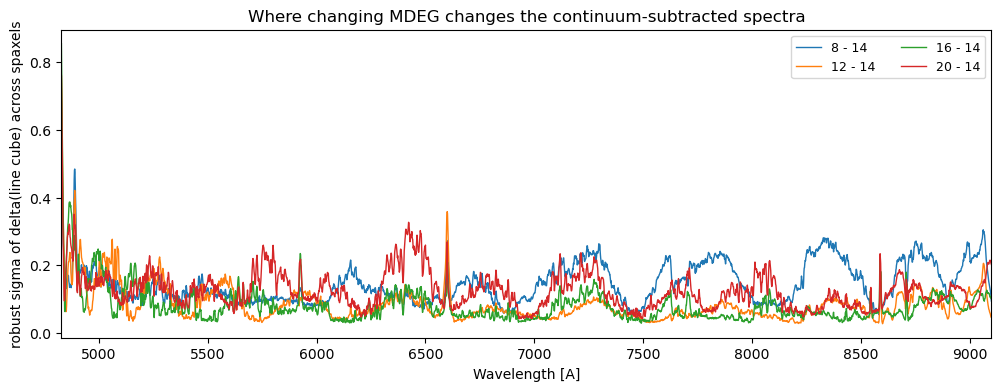

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/4230913543.py:28: RuntimeWarning: All-NaN slice encountered
  ref_map = np.nanmedian(line_cube[REF_MDEG][wm, :, :], axis=0)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_20079/4230913543.py:30: RuntimeWarning: All-NaN slice encountered
  m = np.nanmedian(line_cube[mdeg][wm, :, :], axis=0)


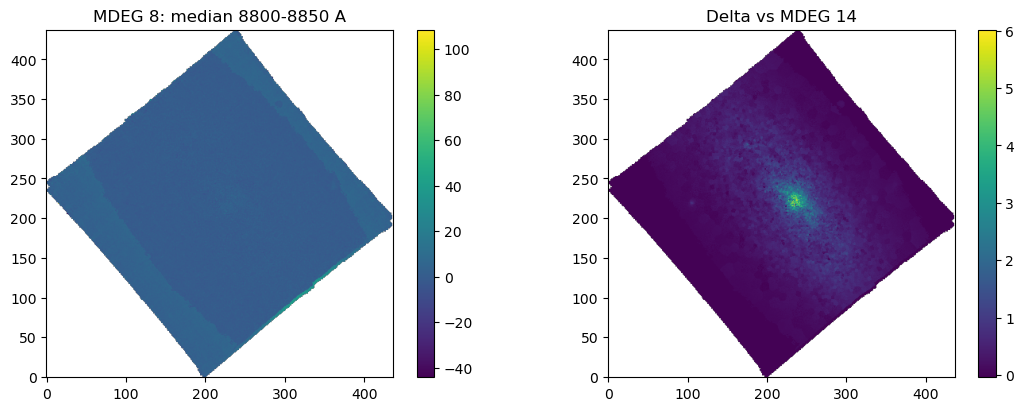

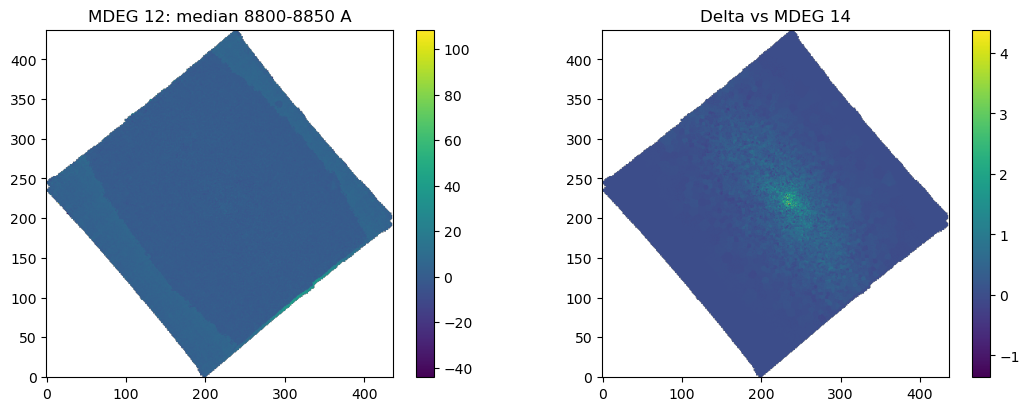

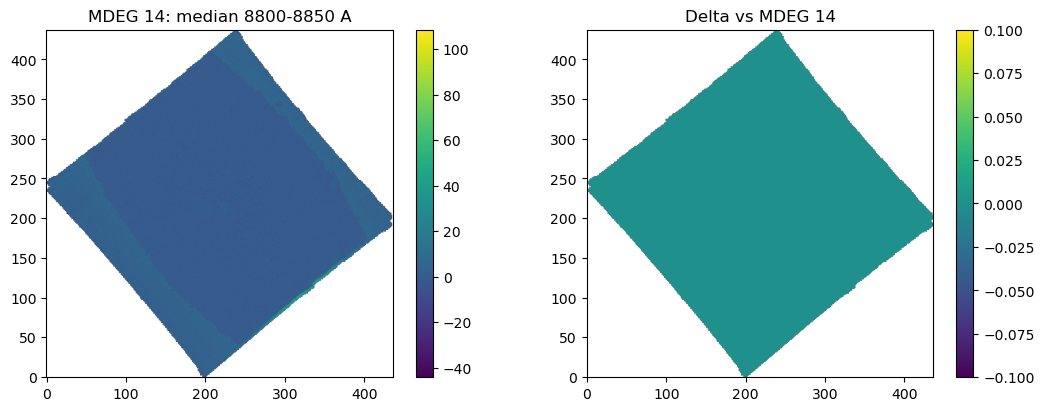

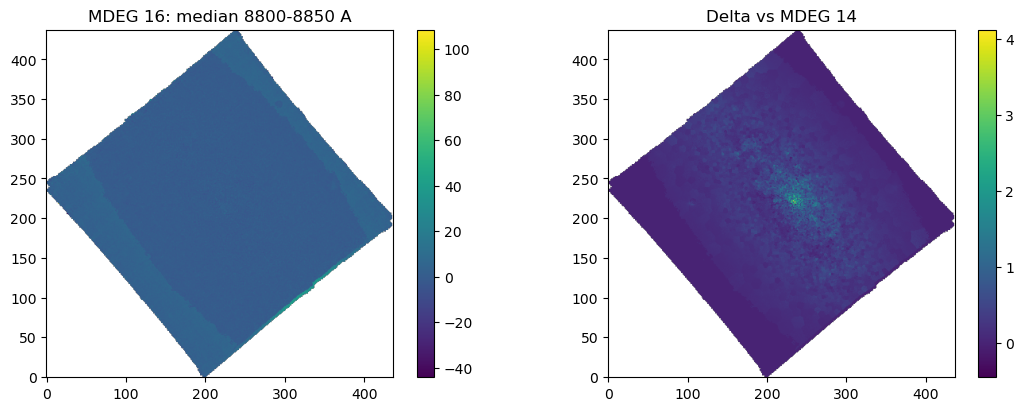

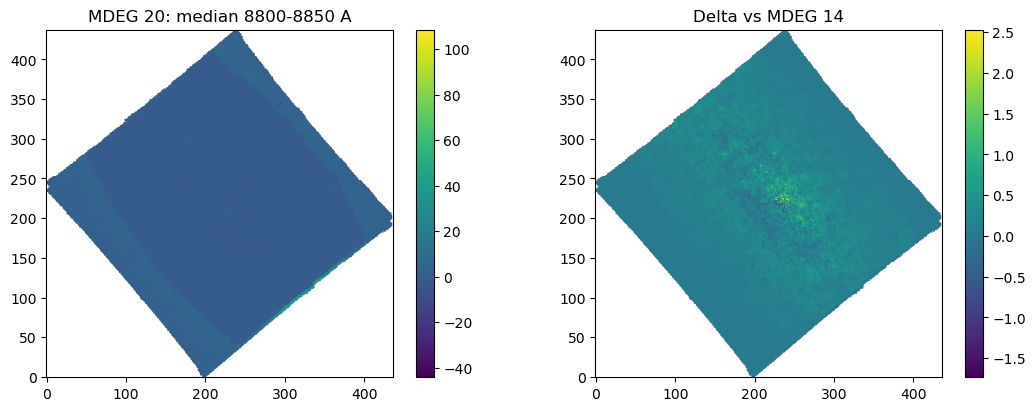

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def robust_sigma_mad_1d(A, axis=1):
    med = np.nanmedian(A, axis=axis)
    mad = np.nanmedian(np.abs(A - np.expand_dims(med, axis=axis)), axis=axis)
    return 1.4826 * mad

# 1) Spectral fingerprint: robust sigma of delta(line cube) vs wavelength
plt.figure(figsize=(12, 4))
for mdeg in sorted(run_ids):
    if mdeg == REF_MDEG:
        continue
    S = line_cube[mdeg][sel, :, :][:, ys, xs].astype(np.float32, copy=False)
    D = S - Sref
    sig = robust_sigma_mad_1d(D, axis=1)
    plt.plot(wave_sel, sig, lw=1, label=f"{mdeg} - {REF_MDEG}")
plt.xlabel("Wavelength [A]")
plt.ylabel("robust sigma of delta(line cube) across spaxels")
plt.title("Where changing MDEG changes the continuum-subtracted spectra")
plt.legend(ncol=2, fontsize=9)
plt.xlim(wave_sel.min(), wave_sel.max())
plt.show()

# 2) 2D baseline maps in a red line-free window
w1, w2 = (8800.0, 8850.0)
wm = (wave >= w1) & (wave <= w2)
ref_map = np.nanmedian(line_cube[REF_MDEG][wm, :, :], axis=0)
for mdeg in sorted(run_ids):
    m = np.nanmedian(line_cube[mdeg][wm, :, :], axis=0)
    dm = m - ref_map
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    im0 = axes[0].imshow(m, origin="lower")
    axes[0].set_title(f"MDEG {mdeg}: median {w1:.0f}-{w2:.0f} A")
    fig.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(dm, origin="lower")
    axes[1].set_title(f"Delta vs MDEG {REF_MDEG}")
    fig.colorbar(im1, ax=axes[1])
    plt.show()

In [8]:
import numpy as np
import pandas as pd

# Simple scorecard across line-free windows
rows = []
for mdeg in sorted(run_ids):
    meds = []
    rmsconts = []
    for wn in linefree_names:
        d = window_summary.get(wn, {}).get(mdeg)
        if not d:
            continue
        meds.append(abs(d["med_p50"]))
        rmsconts.append(d["rmscont_p50"])
    rows.append({
        "mdeg": mdeg,
        "bias_med_abs_p50": np.nanmedian(meds) if len(meds) else np.nan,
        "rmscont_p50": np.nanmedian(rmsconts) if len(rmsconts) else np.nan,
    })
score_df = pd.DataFrame(rows)

def line_stability_score(df, line_cols, ref_mdeg, signal_pctl=LINE_SIGNAL_PCTL, min_n=50):
    scores = {mdeg: [] for mdeg in sorted(run_ids.keys()) if mdeg != ref_mdeg}
    for col in line_cols:
        wide = df.pivot_table(index=["y", "x"], columns="mdeg", values=col, aggfunc="median")
        if ref_mdeg not in wide.columns:
            continue
        ref = wide[ref_mdeg]
        ok = np.isfinite(ref)
        if ok.sum() == 0:
            continue
        thr = np.nanpercentile(np.abs(ref[ok]), signal_pctl)
        ok &= (np.abs(ref) > thr)
        if ok.sum() == 0:
            continue
        dfrac = (wide.sub(ref, axis=0)).div(ref.replace(0, np.nan), axis=0) * 100.0
        for mdeg in scores.keys():
            if mdeg not in dfrac.columns:
                continue
            vals = dfrac[mdeg][ok]
            vals = vals[np.isfinite(vals)]
            if vals.size < min_n:
                continue
            scores[mdeg].append(np.nanmedian(np.abs(vals)))
    rows = []
    for mdeg, vals in scores.items():
        rows.append({
            "mdeg": mdeg,
            "line_stability_p50": np.nanmedian(vals) if len(vals) else np.nan,
        })
    return pd.DataFrame(rows)

line_cols = [c for c in df.columns if c.startswith("F_")]
line_score_df = line_stability_score(df, line_cols, REF_MDEG)
score_df = score_df.merge(line_score_df, on="mdeg", how="left")
score_df = score_df.sort_values(["rmscont_p50", "bias_med_abs_p50", "line_stability_p50"])
score_df

,mdeg,bias_med_abs_p50,rmscont_p50,line_stability_p50
3,16,0.367917,0.169338,1.217566
4,20,0.268303,0.169690,1.931305
2,14,0.325197,0.169983,NaN
1,12,0.332085,0.170616,1.199894
0,8,0.166613,0.170991,1.896658


In [9]:
import numpy as np
import pandas as pd

def p50(df, col):
    return df.groupby("mdeg")[col].median()

core = pd.DataFrame({
    "baseline_leak_p50": p50(df, "baseline_leak"),
    "sky_rms_p50": p50(df, "sky_rms"),
    "diff_linefree_p50": p50(df, "diff_linefree"),
})

# Add a single “line stability” number: median absolute fractional change across key lines vs REF
flux_cols = [c for c in df.columns if c.startswith("F_")]
line_stab = {}
for col in flux_cols:
    wide = df.pivot_table(index=["y","x"], columns="mdeg", values=col, aggfunc="median")
    ref = wide[REF_MDEG]
    dfrac = (wide.sub(ref, axis=0)).div(ref.replace(0, np.nan), axis=0)
    for mdeg in wide.columns:
        if mdeg == REF_MDEG:
            continue
        line_stab.setdefault(mdeg, []).append(np.nanmedian(np.abs(dfrac[mdeg])))

core["line_stab_med_abs_dfrac"] = np.nan
core.loc[REF_MDEG, "line_stab_med_abs_dfrac"] = 0.0
for mdeg, vals in line_stab.items():
    core.loc[mdeg, "line_stab_med_abs_dfrac"] = np.nanmedian(vals)

# Normalize + sum (lower better)
norm = (core - core.min()) / (core.max() - core.min())
core["score"] = norm.sum(axis=1)

core.sort_values("score")


,baseline_leak_p50,sky_rms_p50,diff_linefree_p50,line_stab_med_abs_dfrac,score
mdeg,,,,,
14,0.856379,5.543279,0.000000,0.000000,1.662110
20,0.781919,5.502790,0.058976,0.027925,1.859644
16,0.820618,5.507726,0.045779,0.018675,1.872106
8,0.820546,5.524530,0.064061,0.029738,2.877510
12,0.872539,5.550966,0.048951,0.016354,3.314067
